# Phase 1 — Data Pre-processing Demonstration

This notebook documents how the **Natural Questions** dataset is cleaned, chunked and enriched with metadata before being embedded (Gemini) and indexed (Qdrant).

Steps:
1. Load the raw CSV and inspect it
2. Clean text (strip HTML tags, fix tokenization artifacts)
3. Enrich metadata (question type, domain, difficulty, answer length)
4. Apply sentence-aware chunking
5. Review the resulting distributions

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
from app.config import get_settings
from app.rag.preprocessing import (
    clean_text, classify_question_type, classify_domain,
    classify_difficulty, build_documents, dataset_statistics,
)
settings = get_settings()
csv_path = settings.resolve(settings.dataset_path)
csv_path

WindowsPath('E:/DIGISTED_TASK/dataset/Natural-Questions-Filtered.csv')

## 1. Load and inspect the raw data

In [2]:
df = pd.read_csv(csv_path)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Nulls:\n', df.isna().sum())
df.head()

Shape: (86212, 3)
Columns: ['question', 'long_answers', 'short_answers']
Nulls:
 question         0
long_answers     0
short_answers    0
dtype: int64


,question,long_answers,short_answers
0,which is the most common use of opt-in e-mail ...,A common example of permission marketing is a ...,A newsletter sent to an advertising firm's cus...
1,how i.met your mother who is the mother,"Tracy McConnell, better known as `` The Mother...",Tracy McConnell
2,who had the most wins in the nfl,Active quarterback Tom Brady holds the records...,Tom Brady
3,who played mantis guardians of the galaxy 2,Pom Klementieff (born May 1986) is a French ac...,Pom Klementieff
4,the nashville sound brought a polished and cos...,"In the early 1960s, the Nashville sound began ...",The use of lush string arrangements with a rea...


## 2. Text cleaning
Raw answers can contain `<P>` tags and tokenization artifacts like `` `` `` and ` 's`.

In [3]:
sample = df['long_answers'].iloc[0]
print('RAW   :', sample[:200])
print('CLEAN :', clean_text(sample)[:200])

RAW   : A common example of permission marketing is a newsletter sent to an advertising firm's customers. Such newsletters inform customers of upcoming events or promotions, or new products. In this type of a
CLEAN : A common example of permission marketing is a newsletter sent to an advertising firm's customers. Such newsletters inform customers of upcoming events or promotions, or new products. In this type of a


## 3. Metadata enrichment
Each QA pair is tagged with a question type, domain, difficulty and answer-length bucket.

In [5]:
for _, row in df.head(8).iterrows():
    q = clean_text(row['question'])
    la = clean_text(row['long_answers'])
    sa = clean_text(row['short_answers'])
    print(f"Q: {q[:70]}")
    print(f"   type={classify_question_type(q)} | domain={classify_domain(q, la)} | difficulty={classify_difficulty(sa, la)}")
    print()

Q: which is the most common use of opt-in e-mail marketing
   type=boolean | domain=technology | difficulty=medium

Q: how i.met your mother who is the mother
   type=boolean | domain=entertainment | difficulty=medium

Q: who had the most wins in the nfl
   type=person | domain=sports | difficulty=medium

Q: who played mantis guardians of the galaxy 2
   type=person | domain=entertainment | difficulty=medium

Q: the nashville sound brought a polished and cosmopolitan sound to count
   type=factual | domain=entertainment | difficulty=medium

Q: who needs to be in the car with a permit driver
   type=factual | domain=geography | difficulty=easy

Q: god's not dead a light in the darkness release date
   type=factual | domain=entertainment | difficulty=medium

Q: who is the current president of un general assembly
   type=person | domain=history | difficulty=easy



## 4. Full pipeline: build chunked, enriched documents

In [6]:
docs = build_documents(str(csv_path), max_rows=1000,
                       chunk_size=settings.chunk_size,
                       chunk_overlap=settings.chunk_overlap)
print('Total chunks:', len(docs))
docs[0].to_payload()


c:\Users\EXPRESS\Anaconda3\envs\QA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (631 > 512). Running this sequence through the model will result in indexing errors


Total chunks: 1012


{'text': "Question: which is the most common use of opt-in e-mail marketing\nAnswer: A common example of permission marketing is a newsletter sent to an advertising firm's customers. Such newsletters inform customers of upcoming events or promotions, or new products. In this type of advertising, a company that wants to send a newsletter to their customers may ask them at the point of purchase if they would like to receive the newsletter.",
 'question': 'which is the most common use of opt-in e-mail marketing',
 'short_answer': "A newsletter sent to an advertising firm's customers",
 'long_answer': "A common example of permission marketing is a newsletter sent to an advertising firm's customers. Such newsletters inform customers of upcoming events or promotions, or new products. In this type of advertising, a company that wants to send a newsletter to their customers may ask them at the point of purchase if they would like to receive the newsletter.",
 'question_type': 'boolean',
 'doma

In [7]:
bad = []

for i, d in enumerate(docs):
    n = d.metadata.get("token_count", 0)
    if n > 512:
        bad.append((i, n, d.page_content[:200]))

print("bad chunks:", len(bad))
print(bad[:5])

bad chunks: 0
[]


## 5. Distribution report

In [8]:
import json
stats = dataset_statistics(docs)
print(json.dumps(stats, indent=2))

{
  "total_chunks": 1012,
  "unique_questions": 1000,
  "avg_chunks_per_question": 1.01,
  "avg_chunk_chars": 593.0,
  "avg_chunk_tokens": 143.3,
  "max_chunk_tokens": 376,
  "by_question_type": {
    "factual": 215,
    "person": 179,
    "temporal": 166,
    "boolean": 158,
    "location": 142,
    "definition": 87,
    "quantity": 50,
    "reason": 9,
    "selection": 6
  },
  "by_domain": {
    "entertainment": 407,
    "geography": 169,
    "history": 115,
    "sports": 103,
    "general": 88,
    "politics": 47,
    "technology": 35,
    "science": 33,
    "health": 15
  },
  "by_difficulty": {
    "medium": 873,
    "easy": 139
  },
  "by_answer_length": {
    "long": 538,
    "medium": 397,
    "short": 77
  }
}


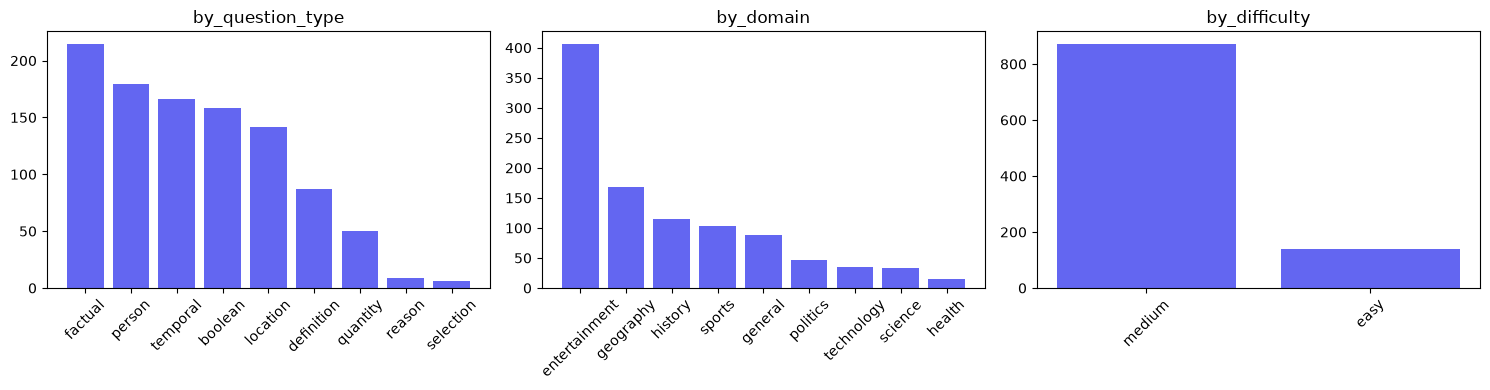

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key in zip(axes, ['by_question_type', 'by_domain', 'by_difficulty']):
    d = stats[key]
    ax.bar(list(d.keys()), list(d.values()), color='#6366f1')
    ax.set_title(key)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()